# Supp Fig 7 — scRNA-seq labels agree + deconvolution-consistent

Reproduces **SuppFig7** by inlining the actual generating code from the source notebooks/scripts. Set the paths in the config cell, then run top-to-bottom. Cost tags: 🟢 light · 🟡 moderate · 🔴 heavy.

## Configuration — edit the paths, then run

In [ ]:
import os, sys, glob, json, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Image
warnings.filterwarnings("ignore")
try:
    import scanpy as sc
    import anndata as ad
except Exception as e:
    print("[note] scanpy/anndata not available:", e)

# ── EDIT THESE PATHS to match your environment ──
REPO_ROOT     = Path("/path/to/spatnic")          # this repository
BACKUP_ROOT   = Path("/path/to/backup")           # integrate_adata_filtered.h5ad, galaxy scores, Liver meta
DATA_ROOT     = Path("/path/to/data")             # GxD concat, lung annotated, c2l refs, spatnic_models, GxD_Xenium
BENCHMARK_DB  = Path("/path/to/benchmark_db")     # Xenium/VisiumHD/MERFISH/CosMx + adata_hvg_*
VISIUMHD_ROOT = Path("/path/to/VisiumHD")         # Visium HD ADC track
WEIGHTS_DIR   = Path.home() / ".spatnic" / "weights"

# ── Derived ──
NB     = REPO_ROOT / "notebooks"
COMP   = NB / "comparison_results"
VHD    = VISIUMHD_ROOT
MODELS = DATA_ROOT / "spatnic_models"
PAPER  = REPO_ROOT / "paper"
BASE_DIR  = VHD          # VisiumHD ADC notebook global
THRESHOLD = 0.9          # overridden to 0.5 by the Fig 5 shortcut setup cell
sys.path[:0] = [str(REPO_ROOT / "scripts"), str(NB)]
if NB.exists():
    os.chdir(NB)         # extracted cells were written for cwd = notebooks/

def _tbl(csv, n=None):
    p = Path(csv)
    if not p.exists():
        print("[missing]", p); return None
    df = pd.read_parquet(p) if str(p).endswith(".parquet") else pd.read_csv(p)
    display(df.head(n) if n else df); return df

def _run(script, show=None, n=None):
    import subprocess
    cmd = f"python notebooks/{script}"
    print("$", cmd)
    r = subprocess.run(cmd, shell=True, cwd=str(REPO_ROOT), capture_output=True, text=True)
    print((r.stdout or "")[-3000:])
    if r.returncode: print("STDERR:\n", (r.stderr or "")[-2000:])
    if show: _tbl(COMP / show, n)


### SFig 7 setup — paths + palette
**🟢 light (reads caches)** · source: `compare_c2l_disagree_FN_FP.ipynb cell 2`

In [ ]:
from pathlib import Path
import gzip, json, warnings
import numpy as np
import pandas as pd
import anndata as ad
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
from scipy.stats import mannwhitneyu

warnings.filterwarnings('ignore')

# Paths
ROOT          = REPO_ROOT
GT_DIR        = ROOT / 'notebooks/comparison_results/visium_v1v2_groundtruth'
C2L_DIR       = DATA_ROOT / 'c2l_minitest'
OUT_DIR       = ROOT / 'notebooks/comparison_results/c2l_disagree_FN_FP'
OUT_DIR.mkdir(parents=True, exist_ok=True)
VISIUM_DATA_ROOT = Path(str(Path.home()/'BICRC')) / 'data'
VISIUM_SR_ROOT   = VISIUM_DATA_ROOT / 'valdeolivas_spaceranger'

DATASETS = ['pelka', 'lee', 'elewaut']
MODE     = 'disagree'

# 13 samples — same registry used everywhere else in this repo
VISIUM_SAMPLES = {
    'SN048_A121573_Rep2':  {'source': 'dsid',        'path': 'DSID001466'},
    'SN123_A595688_Rep1':  {'source': 'dsid',        'path': 'DSID001470'},
    'SN124_A798015_Rep2':  {'source': 'dsid',        'path': 'DSID001475'},
    'SN124_A938797_Rep2':  {'source': 'dsid',        'path': 'DSID001476'},
    'SN84_A120838_Rep2':   {'source': 'dsid',        'path': 'DSID001478'},
    'SN048_A121573_Rep1':  {'source': 'spaceranger', 'path': 'SN048_A121573_Rep1'},
    'SN048_A416371_Rep1':  {'source': 'spaceranger', 'path': 'SN048_A416371_Rep1'},
    'SN048_A416371_Rep2':  {'source': 'spaceranger', 'path': 'SN048_A416371_Rep2'},
    'SN84_A120838_Rep1':   {'source': 'spaceranger', 'path': 'SN84_A120838_Rep1'},
    'SN123_A551763_Rep1':  {'source': 'spaceranger', 'path': 'SN123_A551763_Rep1'},
    'SN123_A798015_Rep1':  {'source': 'spaceranger', 'path': 'SN123_A798015_Rep1'},
    'SN123_A938797_Rep1_X':{'source': 'spaceranger', 'path': 'SN123_A938797_Rep1_X'},
    'SN124_A595688_Rep2':  {'source': 'spaceranger', 'path': 'SN124_A595688_Rep2'},
}

# Project palette — Tumor=#F4B183, Normal=#9DC3E6
C_TUMOR  = '#F4B183'
C_NORMAL = '#9DC3E6'
# 4-group palette: solid for correct, darker for wrong
C_TP = C_TUMOR              # gt=Tumor  & correct
C_TN = C_NORMAL             # gt=Normal & correct
C_FN = '#B8784A'            # gt=Tumor  & SPATNIC=Normal
C_FP = '#5E89B5'            # gt=Normal & SPATNIC=Tumor
GROUP_PALETTE = {'TP': C_TP, 'TN': C_TN, 'FN': C_FN, 'FP': C_FP}
GROUP_ORDER   = ['TP', 'FN', 'FP', 'TN']  # paired by pathology then prediction

### SFig 7 — assign TP/TN/FN/FP groups
**🟢 light (reads caches)** · source: `compare_c2l_disagree_FN_FP.ipynb cell 4`

In [ ]:
preds = pd.read_csv(GT_DIR / 'per_spot_predictions.csv.gz')
print('per_spot_predictions:', preds.shape, '→', list(preds.columns))

# gt_label is the string 'Tumor'/'Normal' (gt_binary is numeric 0/1; we need the string)
def assign_group(row):
    gt, pr = row['gt_label'], row['spatnic_pred']
    if pd.isna(gt) or pd.isna(pr): return None
    if gt == 'Tumor'  and pr == 'Tumor':  return 'TP'
    if gt == 'Tumor'  and pr == 'Normal': return 'FN'
    if gt == 'Normal' and pr == 'Tumor':  return 'FP'
    if gt == 'Normal' and pr == 'Normal': return 'TN'
    return None

preds['group'] = preds.apply(assign_group, axis=1)
preds = preds.dropna(subset=['group']).copy()
print()
print('overall group counts:')
print(preds['group'].value_counts().reindex(GROUP_ORDER))
print()
print('per-sample × group:')
print(preds.groupby('sample')['group'].value_counts().unstack(fill_value=0).reindex(columns=GROUP_ORDER))

### SFig 7 — load 3-ref c2l long
**🔴 heavy (GPU / multi-GB / long)** · source: `compare_c2l_disagree_FN_FP.ipynb cell 6`

In [ ]:
def load_c2l_long(sid: str, dataset: str) -> pd.DataFrame | None:
    p = C2L_DIR / f'{sid}_{dataset}_{MODE}.h5ad'
    if not p.exists():
        print(f'  [missing] {p.name}')
        return None
    a = ad.read_h5ad(p)
    key = 'q05_cell_abundance_w_sf'
    df = a.obsm[key].copy()
    # find Tumor / Normal columns regardless of prefix
    tcol = next(c for c in df.columns if str(c).endswith('Tumor'))
    ncol = next(c for c in df.columns if str(c).endswith('Normal'))
    out = pd.DataFrame({
        'barcode': df.index.astype(str),
        'sample':  sid,
        'dataset': dataset,
        'q05_tumor':  df[tcol].astype(float).values,
        'q05_normal': df[ncol].astype(float).values,
    })
    tot = (out['q05_tumor'] + out['q05_normal']).clip(lower=1e-9)
    out['tumor_frac'] = out['q05_tumor'] / tot
    return out

rows = []
for ds in DATASETS:
    for sid in VISIUM_SAMPLES:
        d = load_c2l_long(sid, ds)
        if d is not None: rows.append(d)
c2l = pd.concat(rows, ignore_index=True)
print(f'\nc2l long table: {c2l.shape}')
print('spots per dataset:', c2l.groupby('dataset').size().to_dict())

### SFig 7 — merge per_spot_c2l_groups
**🟢 light (reads caches)** · source: `compare_c2l_disagree_FN_FP.ipynb cell 8`

In [ ]:
key_cols = ['barcode', 'sample']
preds_keep = preds[key_cols + ['gt_label', 'spatnic_pred', 'spatnic_score', 'group']]
long = c2l.merge(preds_keep, on=key_cols, how='inner')
print(f'merged long table: {long.shape}')
print()
print('per dataset × group counts (across all samples):')
print(long.groupby(['dataset','group']).size().unstack(fill_value=0).reindex(columns=GROUP_ORDER))

long.to_csv(OUT_DIR / 'per_spot_c2l_groups.csv.gz', index=False, compression='gzip')
print(f'\nSaved: {OUT_DIR / "per_spot_c2l_groups.csv.gz"}')

### SFig 7 — paired violin by pathology
**🟡 moderate** · source: `compare_c2l_disagree_FN_FP.ipynb cell 10`

In [ ]:
def paired_violin(ax, df_subset, groups, title):
    """Paired violins per group: Tumor-source (orange) vs Normal-source (blue)."""
    n_g = len(groups)
    positions = np.arange(n_g)
    offset = 0.2  # half-width offset of the pair
    for src, color, off in [('q05_tumor', C_TUMOR, -offset),
                             ('q05_normal', C_NORMAL, +offset)]:
        data = [df_subset.loc[df_subset['group']==g, src].values for g in groups]
        valid_idx = [i for i, d in enumerate(data) if len(d) > 0]
        if not valid_idx:
            continue
        parts = ax.violinplot([data[i] for i in valid_idx],
                              positions=[positions[i]+off for i in valid_idx],
                              widths=0.36, showmeans=False, showmedians=True,
                              showextrema=False)
        for pc in parts['bodies']:
            pc.set_facecolor(color); pc.set_edgecolor('black')
            pc.set_alpha(0.78); pc.set_linewidth(0.6)
        parts['cmedians'].set_color('black'); parts['cmedians'].set_linewidth(1.3)
    ax.set_xticks(positions)
    ax.set_xticklabels([f'{g}\nn={(df_subset["group"]==g).sum()}' for g in groups])
    for sp in ('top','right'): ax.spines[sp].set_visible(False)
    ax.set_title(title, fontsize=11, fontweight='bold')

# Auto y-limit per row based on 99th percentile of *all* tumor and normal abundances
# at that pathology level (across all datasets) — fairer cross-dataset comparison.
def y_max_for(df_subset, pct=99):
    vals = np.concatenate([df_subset['q05_tumor'].values, df_subset['q05_normal'].values])
    return float(np.percentile(vals, pct)) if len(vals) else 1.0

fig, axes = plt.subplots(2, len(DATASETS), figsize=(5.0*len(DATASETS), 9.0),
                          sharey='row')

# Row 0: pathology = Tumor → spots are TP or FN
# Row 1: pathology = Normal → spots are TN or FP
rows_cfg = [
    (0, 'Tumor',  ['TP', 'FN']),
    (1, 'Normal', ['TN', 'FP']),
]
for row_i, gt_class, groups in rows_cfg:
    df_path = long[long['gt_label'] == gt_class]
    ymax = max(y_max_for(df_path[df_path['dataset']==ds]) for ds in DATASETS) * 1.05
    for col_i, ds in enumerate(DATASETS):
        ax = axes[row_i, col_i]
        df_ds = df_path[df_path['dataset']==ds]
        paired_violin(ax, df_ds, groups,
                      title=f'pathology={gt_class}  /  {ds}')
        ax.set_ylim(0, ymax)
        if col_i == 0:
            ax.set_ylabel(f'c2l q05 abundance\n(pathology={gt_class} spots)',
                          fontsize=10)

# Shared legend
handles = [mpatches.Patch(facecolor=C_TUMOR, edgecolor='black', label='Tumor-source'),
           mpatches.Patch(facecolor=C_NORMAL, edgecolor='black', label='Normal-source')]
fig.legend(handles=handles, loc='upper center', ncol=2, frameon=False,
           bbox_to_anchor=(0.5, 1.00), fontsize=11)
fig.suptitle('c2l source abundance by pathology × spot-group  (disagree-mode signature)',
             fontsize=13, fontweight='bold', y=0.99)
fig.tight_layout(rect=[0, 0, 1, 0.96])
for ext in ('png','pdf'):
    fig.savefig(OUT_DIR / f'violin_source_abundance_by_pathology.{ext}',
                dpi=180, bbox_inches='tight')
print(f'Saved: {OUT_DIR / "violin_source_abundance_by_pathology"}.{{png,pdf}}')
plt.show()

### SFig 7 — per-sample paired boxes
**🟡 moderate** · source: `compare_c2l_disagree_FN_FP.ipynb cell 14`

In [ ]:
def per_sample_paired(ds_name, gt_class, groups):
    df_path = long[(long['dataset']==ds_name) & (long['gt_label']==gt_class)]
    samples = [s for s in VISIUM_SAMPLES if (df_path['sample']==s).any()]
    if not samples:
        print(f'  no samples for {ds_name} / {gt_class}')
        return
    n = len(samples)
    ncols = min(5, n); nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(3.4*ncols, 3.0*nrows),
                             sharey=True, squeeze=False)
    offset = 0.2
    positions = np.arange(len(groups))
    # consistent y-limit per ds×gt_class
    ymax = float(np.percentile(
        np.concatenate([df_path['q05_tumor'].values, df_path['q05_normal'].values]),
        99)) * 1.05 if len(df_path) else 1.0
    for i, sid in enumerate(samples):
        ax = axes[i//ncols][i%ncols]
        d = df_path[df_path['sample']==sid]
        for src, color, off in [('q05_tumor', C_TUMOR, -offset),
                                 ('q05_normal', C_NORMAL, +offset)]:
            data = [d.loc[d['group']==g, src].values for g in groups]
            valid_idx = [k for k, dd in enumerate(data) if len(dd) > 0]
            if not valid_idx: continue
            bp = ax.boxplot([data[k] for k in valid_idx],
                            positions=[positions[k]+off for k in valid_idx],
                            widths=0.32, showfliers=False, patch_artist=True,
                            medianprops=dict(color='k', lw=1.0))
            for box in bp['boxes']:
                box.set_facecolor(color); box.set_alpha(0.65); box.set_edgecolor('k')
        ax.set_xticks(positions)
        ax.set_xticklabels([f'{g}\nn={(d["group"]==g).sum()}' for g in groups], fontsize=8)
        ax.set_ylim(0, ymax)
        ax.set_title(sid, fontsize=10)
        for sp in ('top','right'): ax.spines[sp].set_visible(False)
        if i%ncols == 0:
            ax.set_ylabel(f'q05 abundance\n(path={gt_class})', fontsize=9)
    for j in range(n, nrows*ncols):
        axes[j//ncols][j%ncols].axis('off')
    handles = [mpatches.Patch(facecolor=C_TUMOR, edgecolor='black', label='Tumor-src'),
               mpatches.Patch(facecolor=C_NORMAL, edgecolor='black', label='Normal-src')]
    fig.legend(handles=handles, loc='upper right', ncol=2, frameon=False,
               bbox_to_anchor=(0.98, 1.00), fontsize=10)
    fig.suptitle(f'Per-sample paired abundance  ({ds_name} disagree-ref, pathology={gt_class})',
                 fontsize=12, fontweight='bold', y=1.0)
    fig.tight_layout()
    out = OUT_DIR / f'paired_per_sample_{ds_name}_path-{gt_class}'
    for ext in ('png','pdf'):
        fig.savefig(f'{out}.{ext}', dpi=150, bbox_inches='tight')
    plt.show()

for ds in DATASETS:
    per_sample_paired(ds, 'Tumor',  ['TP', 'FN'])
    per_sample_paired(ds, 'Normal', ['TN', 'FP'])
print(f'Saved: {OUT_DIR / "paired_per_sample_*"}.{{png,pdf}}')

## Published result (reference)
Embedded reference output; the code above regenerates it.

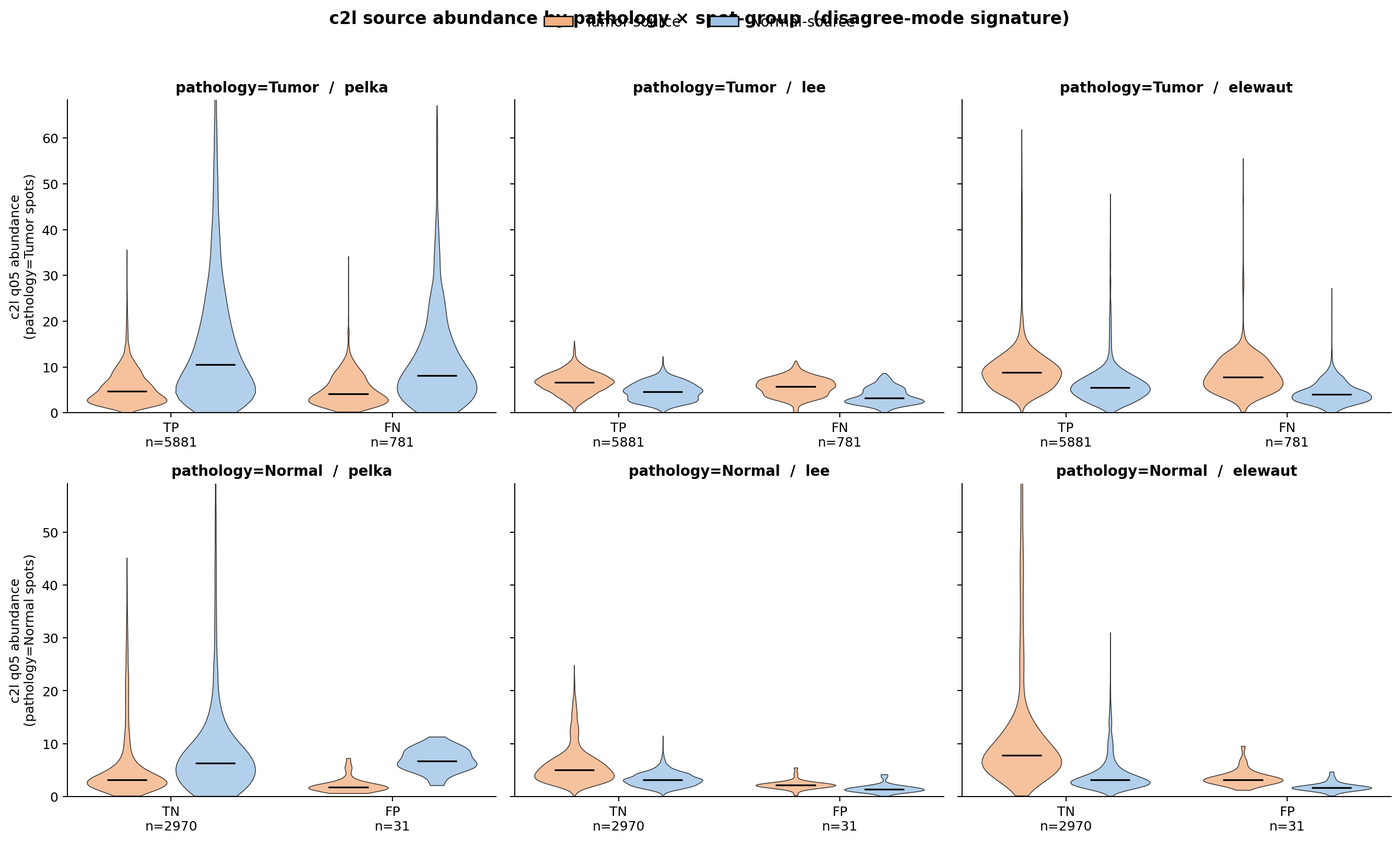

In [ ]:
# q05 abundance by pathology
Image(str(COMP / "c2l_disagree_FN_FP/violin_source_abundance_by_pathology.png"))

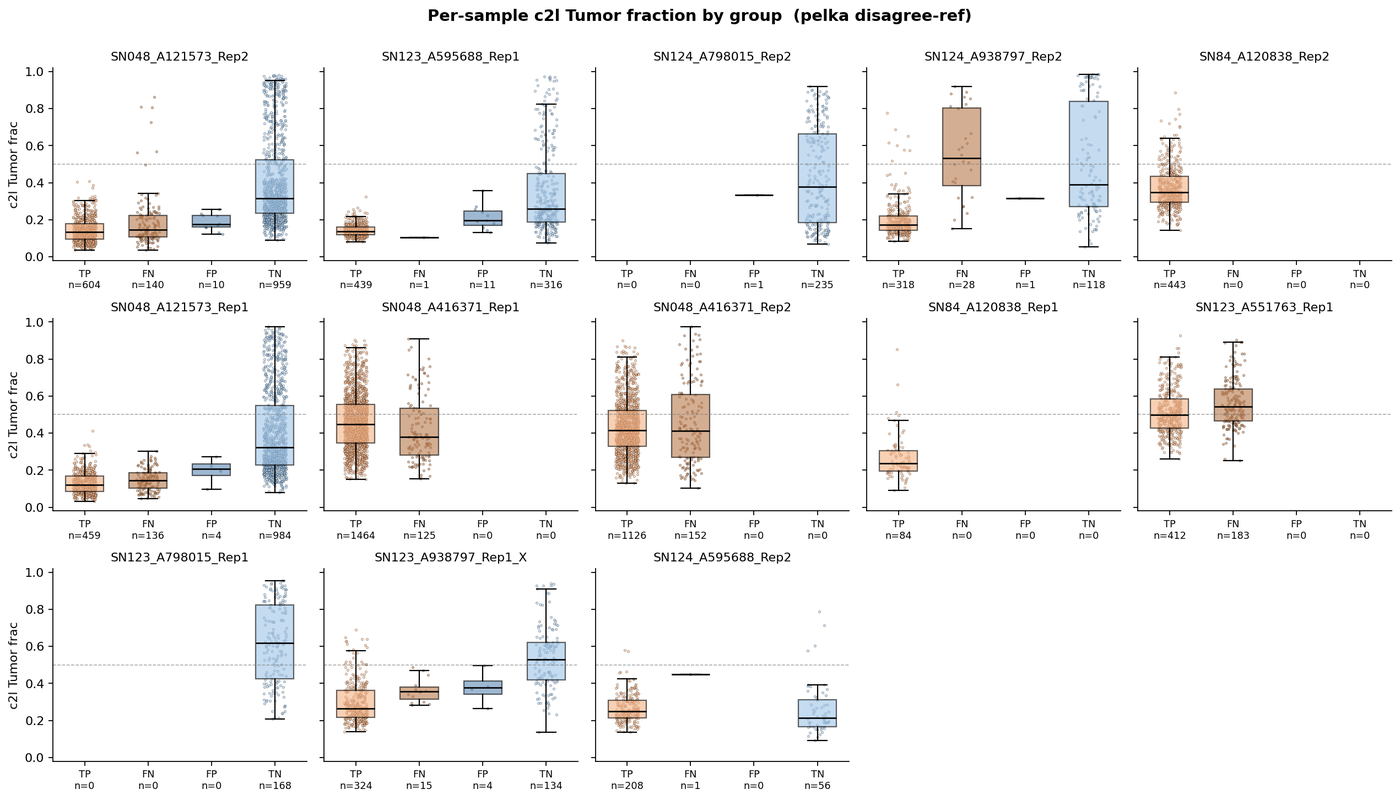

In [ ]:
# Per-sample (Pelka)
Image(str(COMP / "c2l_disagree_FN_FP/boxstrip_per_sample_pelka.png"))